<a href="https://colab.research.google.com/github/Krishna28Gupta/Fake_news_predictor/blob/main/Fake_news_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')


In [3]:
true_df['label'] = 0
fake_df['label'] = 1

In [4]:
df = pd.concat([true_df, fake_df],ignore_index=True)
df.head()


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [5]:
df.isna().sum()

,0
title,0
text,1
subject,1
date,1
label,0


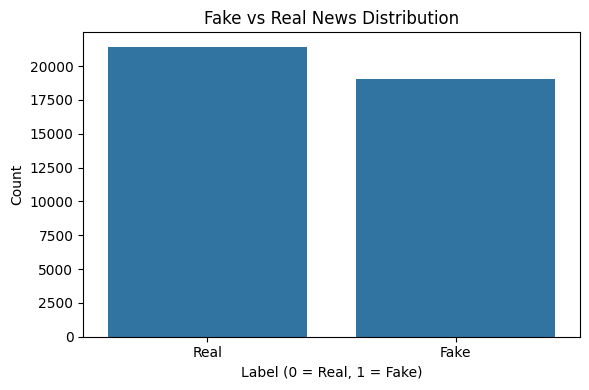

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Real", "Fake"])
plt.tight_layout()
plt.show()

In [7]:
df.drop(['subject', 'date'], axis=1, inplace=True)
df.head(10)

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,0
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",0
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",0
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,0
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,0
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import re

In [9]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shape:", df.shape)
print(df["label"].value_counts())

Dataset shape: (40432, 3)
label
0    21417
1    19015
Name: count, dtype: int64


In [10]:
df["content"] = df["title"] + " " + df["text"]
print("\nSample content (first 200 chars):")
print(df["content"][0][:200])


Sample content (first 200 chars):
 Wait Until You See The Insane Tweet The Official GOP Twitter Account Just Sent Out It appears that someone has possibly hacked the GOP s official Twitter account. On Wednesday evening, they sent out 


In [11]:
def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'\[.*?\]', '', text)          # remove text in brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)         # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

In [13]:
print("\nCleaning text")
df["content"] = df["content"].fillna('') # Fill NaN values with empty strings
df["cleaned"] = df["content"].apply(clean_text)

print("\nOriginal text sample:")
print(df["content"][0][:200])
print("\nCleaned text sample:")
print(df["cleaned"][0][:200])


Cleaning text

Original text sample:
 Wait Until You See The Insane Tweet The Official GOP Twitter Account Just Sent Out It appears that someone has possibly hacked the GOP s official Twitter account. On Wednesday evening, they sent out 

Cleaned text sample:
wait until you see the insane tweet the official gop twitter account just sent out it appears that someone has possibly hacked the gop s official twitter account on wednesday evening they sent out an 


In [14]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X = tfidf.fit_transform(df["cleaned"])
y = df["label"]

print("\n✅ TF-IDF shape:", X.shape)
print("Each article is now represented as a row of 5000 numbers")

feature_names = tfidf.get_feature_names_out()
print("\nSample TF-IDF features (words):", feature_names[:20])


✅ TF-IDF shape: (40432, 5000)
Each article is now represented as a row of 5000 numbers

Sample TF-IDF features (words): ['abadi' 'abandon' 'abandoned' 'abbas' 'abc' 'abdullah' 'abe' 'abedin'
 'ability' 'able' 'abortion' 'abortions' 'abroad' 'absence' 'absolute'
 'absolutely' 'absurd' 'abu' 'abuse' 'abuses']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

print("\n Training Naive Bayes...")
nb = MultinomialNB()
nb.fit(X_train, y_train)

print("\n Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


Training Logistic Regression...

 Training Naive Bayes...

 Training Random Forest...


RandomForestClassifier(random_state=42)

In [18]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1 Score" : round(f1_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9864,0.9886,0.9824,0.9855
1,Naive Bayes,0.9355,0.9258,0.9379,0.9318
2,Random Forest,0.9975,0.9987,0.9961,0.9974


In [19]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n🔹 {name}")
    print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))
    print("-" * 50)


🔹 Logistic Regression
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4284
        Fake       0.99      0.98      0.99      3803

    accuracy                           0.99      8087
   macro avg       0.99      0.99      0.99      8087
weighted avg       0.99      0.99      0.99      8087

--------------------------------------------------

🔹 Naive Bayes
              precision    recall  f1-score   support

        Real       0.94      0.93      0.94      4284
        Fake       0.93      0.94      0.93      3803

    accuracy                           0.94      8087
   macro avg       0.94      0.94      0.94      8087
weighted avg       0.94      0.94      0.94      8087

--------------------------------------------------

🔹 Random Forest
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4284
        Fake       1.00      1.00      1.00      3803

    accuracy             

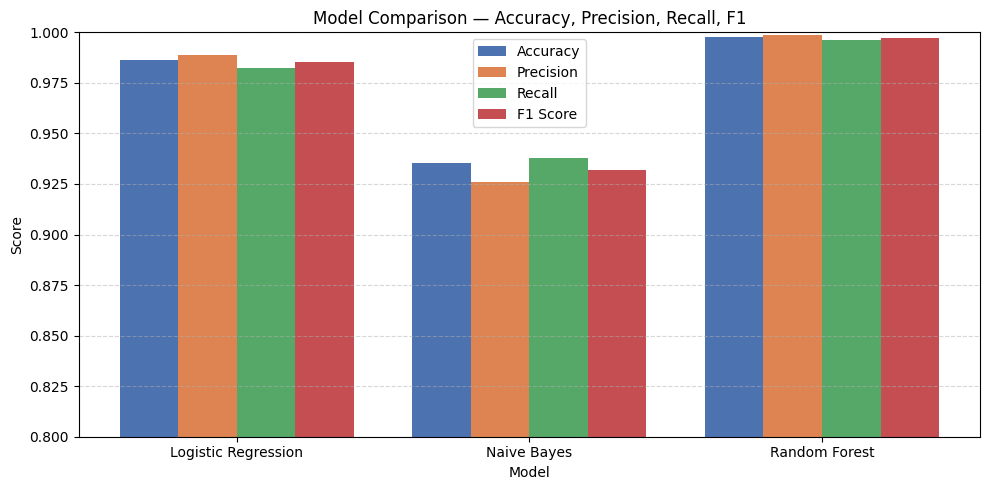

In [20]:
x = np.arange(len(results_df))
width = 0.2
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Accuracy, Precision, Recall, F1")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"])
ax.set_ylim(0.8, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

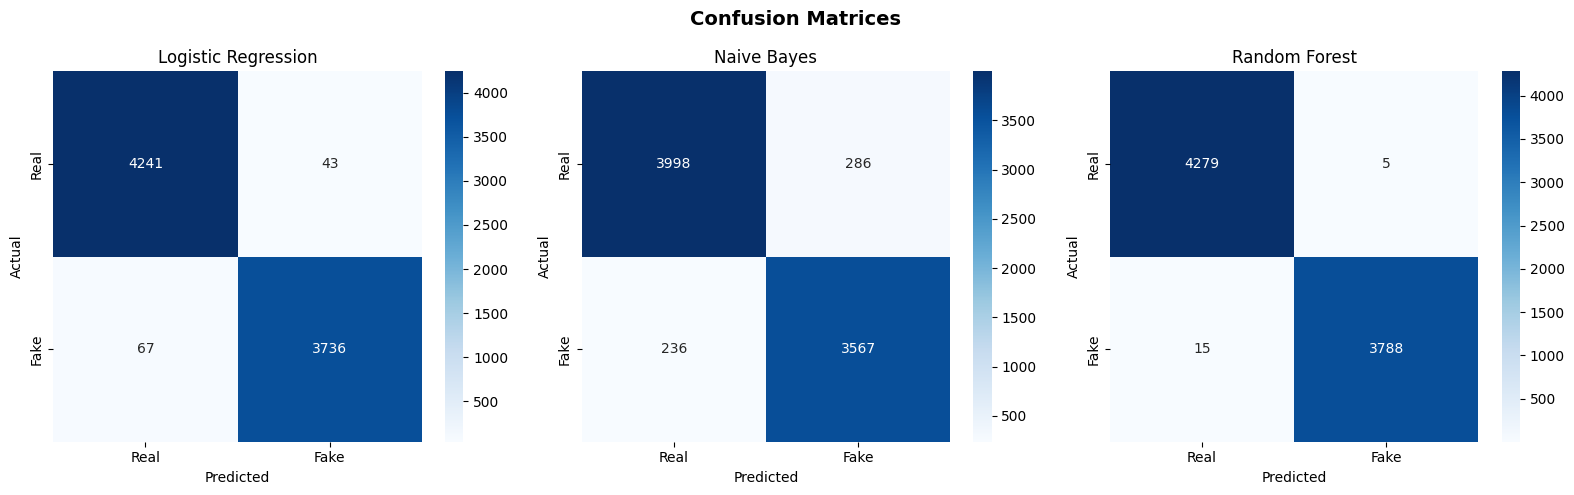

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
import re

def predict_news(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    vector = tfidf.transform([text])
    prediction = lr.predict(vector)[0]
    confidence = lr.predict_proba(vector)[0][prediction] * 100

    label = "🚨 FAKE NEWS" if prediction == 1 else "✅ REAL NEWS"
    print(f"Prediction  : {label}")
    print(f"Confidence  : {confidence:.2f}%")

predict_news("Scientists discover new vaccine that cures all diseases overnight")

Prediction  : 🚨 FAKE NEWS
Confidence  : 67.94%
